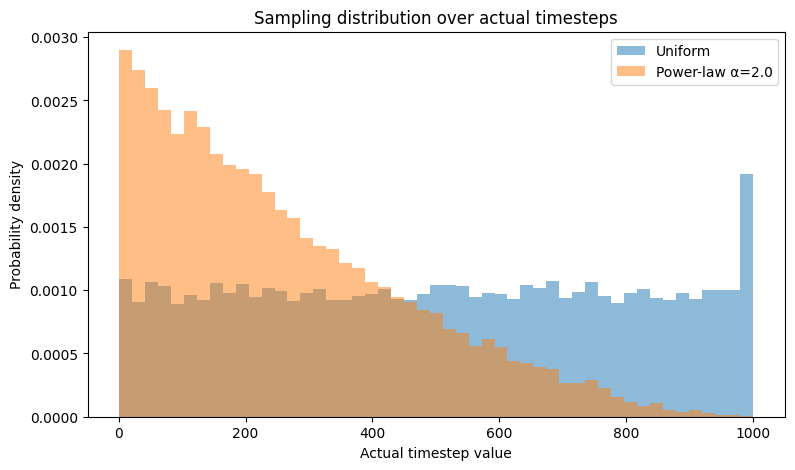

In [8]:
# Jupyter-ready cell: sampling biased toward lower timesteps (show actual timestep values)
import torch
import numpy as np
import matplotlib.pyplot as plt

def sample_timestep_biased(timesteps, rng=None, alpha=2.0, mode="powerlaw", return_index=False):
    """
    Sample a timestep index/value with bias toward lower timesteps (later steps).

    Parameters
    ----------
    timesteps : list or torch.Tensor
        List of timesteps (e.g., from pipe.scheduler.timesteps), typically descending.
    rng : torch.Generator or None
        Random generator for reproducibility.
    alpha : float
        Bias strength for 'powerlaw' mode (alpha>0 favors lower timesteps).
    mode : str
        'uniform', 'powerlaw', or 'exponential'
    return_index : bool
        If True, returns index; else returns timestep value.
    """
    t = torch.as_tensor(timesteps, dtype=torch.float32)
    N = len(t)
    idxs = torch.arange(N, dtype=torch.float32)

    if mode == "uniform":
        probs = torch.ones(N)
    elif mode == "powerlaw":
        x = (idxs + 1) / N
        probs = x ** alpha
    elif mode == "exponential":
        beta = alpha
        x = (idxs + 1) / N
        probs = torch.exp(beta * x)
    else:
        raise ValueError(f"Unknown mode '{mode}'")

    probs = probs / probs.sum()

    if rng is None:
        rng = torch.Generator()
    idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=rng).item()

    return idx if return_index else t[idx].item()


# ---------------------------------------------------------
# Updated visualization — show ACTUAL TIMESTEP values
# ---------------------------------------------------------
def demo_sampling(timesteps=None, alpha=2.0, n_samples=20000, seed=123):
    if timesteps is None:
        timesteps = torch.linspace(1000, 1, 50)  # synthetic descending
    g = torch.Generator().manual_seed(seed)

    # Draw samples
    uniform_ts = [sample_timestep_biased(timesteps, g, mode="uniform") for _ in range(n_samples)]
    biased_ts  = [sample_timestep_biased(timesteps, g, alpha=alpha, mode="powerlaw") for _ in range(n_samples)]

    # Plot histogram by actual timestep values
    plt.figure(figsize=(9,5))
    bins = np.linspace(min(timesteps), max(timesteps), len(timesteps))
    plt.hist(uniform_ts, bins=bins, density=True, alpha=0.5, label="Uniform")
    plt.hist(biased_ts, bins=bins, density=True, alpha=0.5, label=f"Power-law α={alpha}")
    plt.xlabel("Actual timestep value")
    plt.ylabel("Probability density")
    plt.title("Sampling distribution over actual timesteps")
    plt.legend()
    plt.show()


# Example
demo_sampling()


Timesteps shape: torch.Size([50]) min/max: 1.0 1000.0
Sum(probs_alpha)=1.000000 | Sum(probs_uniform)=1.000000
Top-5 (alpha=1.0) indices by prob: [49 48 47 46 45] → timesteps: [1.0, 21.387754440307617, 41.775508880615234, 62.16326141357422, 82.55101776123047]


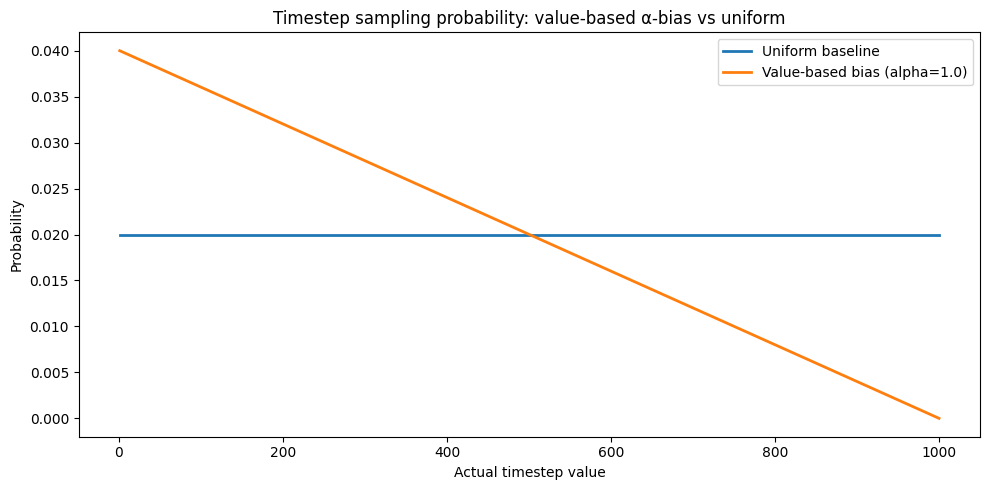

In [12]:
# Jupyter-ready visualization comparing value-based α-bias vs. uniform baseline
# Uses your `_value_based_probs_divmax` function exactly as specified.
# Single chart, matplotlib only, default colors.

import numpy as np
import torch
import matplotlib.pyplot as plt

# --------- Your function (unchanged) ---------
def _value_based_probs_divmax(timesteps: torch.Tensor, alpha: float) -> np.ndarray:
    """
    Compute bias directly from timestep values.
    Normalize by dividing by max(t). This ensures scale invariance and simplicity.

    We map lower timesteps → higher probability:
        s = 1 - (t / t_max)
        p ∝ s^alpha
    """
    t = timesteps.detach().to(torch.float32).flatten()
    t_max = torch.max(t)
    if t_max <= 0:
        probs = torch.ones_like(t) / t.numel()
        return probs.cpu().numpy()

    s = 1.0 - (t / t_max)      # 0 at largest (earliest), 1 at smallest (latest)
    s = s.clamp(0.0, 1.0)
    probs = torch.pow(s, alpha)
    if torch.sum(probs) <= 0:
        probs = torch.ones_like(probs)
    probs = probs / probs.sum()
    return probs.cpu().numpy()

# --------- Config (edit here) ---------
ALPHA = 1.0            # >0 biases toward lower timesteps (later steps)
NUM_STEPS = 50         # used only if we synthesize timesteps
TIMESTEPS = None       # set to your real pipe.scheduler.timesteps to use actual values

# --------- Prepare timesteps ---------
if TIMESTEPS is None:
    # Synthetic descending timesteps (like Diffusers): 1000..1
    timesteps = torch.linspace(1000, 1, NUM_STEPS, dtype=torch.float32)
else:
    timesteps = torch.as_tensor(TIMESTEPS, dtype=torch.float32)

# --------- Compute probabilities ---------
probs_alpha  = _value_based_probs_divmax(timesteps, ALPHA)
probs_uniform = np.ones_like(probs_alpha) / probs_alpha.size

# --------- Print quick sanity checks ---------
print("Timesteps shape:", timesteps.shape, "min/max:", float(timesteps.min()), float(timesteps.max()))
print(f"Sum(probs_alpha)={probs_alpha.sum():.6f} | Sum(probs_uniform)={probs_uniform.sum():.6f}")

# Report the top-5 most likely timesteps for the chosen alpha
timesteps_np = timesteps.cpu().numpy()
top5_idx = np.argsort(probs_alpha)[-5:][::-1]
print(f"Top-5 (alpha={ALPHA}) indices by prob:", top5_idx, "→ timesteps:", timesteps_np[top5_idx].tolist())

# --------- Visualization (single plot) ---------
plt.figure(figsize=(10, 5))
# Sort by timestep ascending for a left→right increasing x-axis
order = np.argsort(timesteps_np)
x_sorted = timesteps_np[order]
pa_sorted = probs_alpha[order]
pu_sorted = probs_uniform[order]

plt.plot(x_sorted, pu_sorted, linewidth=2, label="Uniform baseline")
plt.plot(x_sorted, pa_sorted, linewidth=2, label=f"Value-based bias (alpha={ALPHA})")
plt.xlabel("Actual timestep value")
plt.ylabel("Probability")
plt.title("Timestep sampling probability: value-based α-bias vs uniform")
plt.legend()
plt.tight_layout()
plt.show()
